# RPA Strategies Demo

Demonstrates the three treatment strategies for the six SN5.2 RPA networks.
Models and strategies are imported from the `rpa_control` package.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from IPython.display import display

from rpa_control.models import (
    RPAModel, ALL_MODELS,
    model_a, model_b, model_c, model_d, model_e, model_f,
    model_if, model_iffl, model_abc,
)
from rpa_control.simulation import (
    simulate_rpa_on_off, simulate_rpa_intermittent,
    validate_rpa_params, print_validation_results,
    classify_rpa_params,
    stepped_trajectory, eval_ss,
)
from rpa_control.strategies import (
    ResonanceStrategy, run_resonance_demo,
    SensitizationStrategy, run_sensitization_demo,
    SeparationOfTimescalesStrategy, run_sot_demo,
)

## Models

The six SN5.2 networks from Araujo & Liotta (2018), plus the IF and IFFL reference models.

In [2]:
for model in ALL_MODELS:
    display(model)

RPAModel('a', output='O', rpa_params=['k1', 'k2', 'k3', 'Input'])

RPAModel('b', output='O', rpa_params=['k1', 'k2', 'k5', 'k7', 'Input'])

RPAModel('c', output='O', rpa_params=['k1', 'k2', 'k3', 'k9', 'k10', 'k11', 'Input'])

RPAModel('d', output='O', rpa_params=['k1', 'k2', 'k3', 'k4', 'k5', 'k8', 'k9', 'k10', 'Input'])

RPAModel('e', output='O', rpa_params=['k1', 'k2', 'k6', 'k7', 'k8', 'Input'])

RPAModel('f', output='O', rpa_params=['k1', 'k2', 'k3', 'k6', 'k7', 'k8', 'k11', 'k12', 'k13', 'Input'])

In [3]:
display(model_if)
display(model_iffl)

RPAModel('IF', output='B', rpa_params=['alpha', 'beta1', 'beta2'])

RPAModel('IFFL', output='y', rpa_params=['Input'])

## RPA parameter validation

For each model and each declared RPA parameter, run the ODE at the base value
and at `scale × base` and verify O reaches the same steady state.

In [4]:
for model in ALL_MODELS:
    results = validate_rpa_params(model)
    print_validation_results(model, results)

[PASS] Case a  (4/4 params)
  ✓ k1     base=1.000 → 2.000  |  O*= 0.75000  vs  0.75000  (rel Δ = 1.5e-16)
  ✓ k2     base=0.500 → 1.000  |  O*= 0.75000  vs  0.75000  (rel Δ = 1.0e-15)
  ✓ k3     base=1.000 → 2.000  |  O*= 0.75000  vs  0.75000  (rel Δ = 1.0e-15)
  ✓ Input  base=1.000 → 2.000  |  O*= 0.75000  vs  0.75000  (rel Δ = 1.5e-16)
[PASS] Case b  (5/5 params)
  ✓ k1     base=1.000 → 2.000  |  O*= 0.50000  vs  0.50000  (rel Δ = 8.9e-16)
  ✓ k2     base=1.000 → 2.000  |  O*= 0.50000  vs  0.50000  (rel Δ = 4.4e-16)
  ✓ k5     base=0.500 → 1.000  |  O*= 0.50000  vs  0.50000  (rel Δ = 1.1e-15)
  ✓ k7     base=1.000 → 2.000  |  O*= 0.50000  vs  0.50000  (rel Δ = 2.2e-16)
  ✓ Input  base=1.000 → 2.000  |  O*= 0.50000  vs  0.50000  (rel Δ = 8.9e-16)
[PASS] Case c  (7/7 params)
  ✓ k1     base=1.000 → 2.000  |  O*= 0.50000  vs  0.50000  (rel Δ = 0.0e+00)
  ✓ k2     base=0.500 → 1.000  |  O*= 0.50000  vs  0.50000  (rel Δ = 1.1e-16)
  ✓ k3     base=1.000 → 2.000  |  O*= 0.50000  vs  0.50000

## RPA parameter direction classification

Step each RPA parameter to 2× baseline and classify the output transient:
- **blue** — positive (O rises above O*)
- **red**  — negative (O drops below O*)
- **gray** — none (no significant change)

Model a:  pos=['k1', 'Input']  neg=['k2', 'k3']  none=[]
Model b:  pos=['k1', 'k5', 'Input']  neg=['k2', 'k7']  none=[]
Model c:  pos=['k1', 'k9', 'Input']  neg=['k2', 'k3', 'k10', 'k11']  none=[]
Model d:  pos=['k1', 'k4', 'k9', 'k10', 'Input']  neg=['k2', 'k3', 'k5', 'k8']  none=[]
Model e:  pos=['k1', 'k6', 'Input']  neg=['k2', 'k7', 'k8']  none=[]
Model f:  pos=['k1', 'k6', 'k13', 'Input']  neg=['k2', 'k3', 'k8', 'k12']  none=['k7', 'k11']


/tmp/ipykernel_12426/4133736979.py:52: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


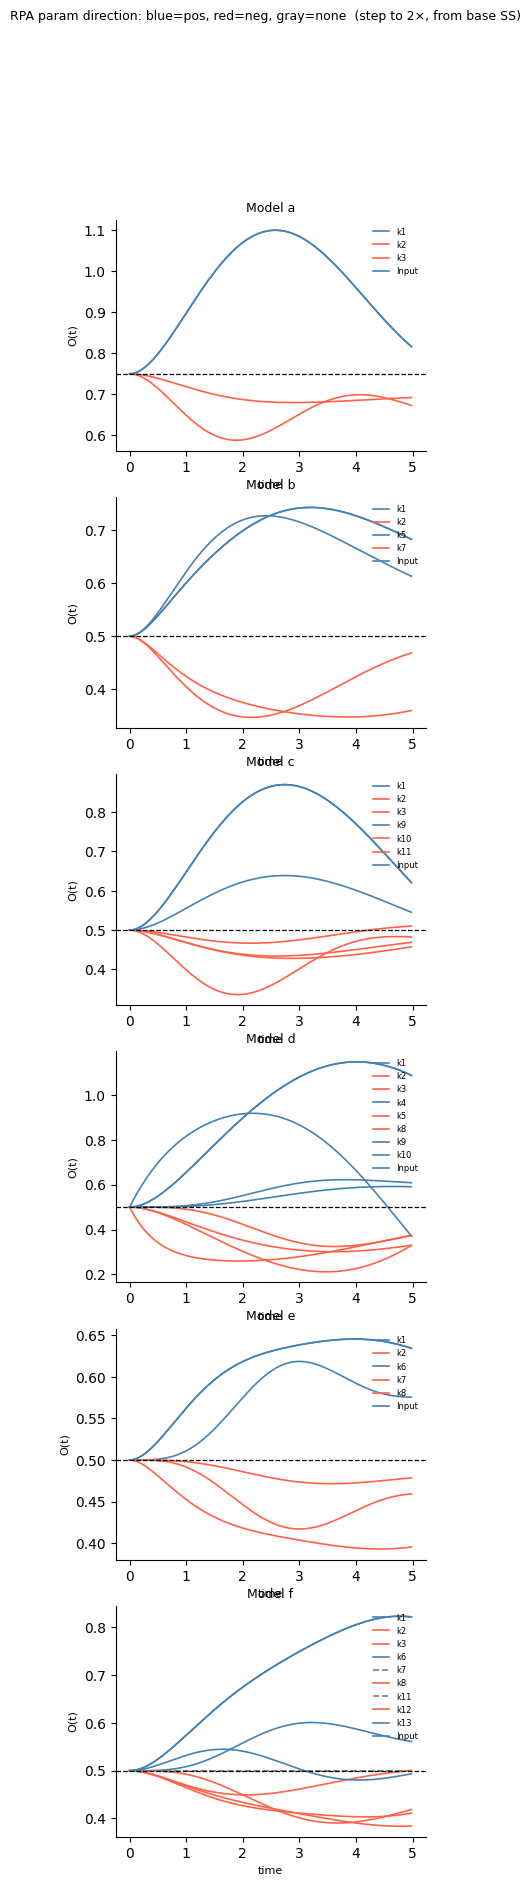

In [5]:
from scipy.integrate import solve_ivp as _siv

T_STEP  = 5.0
DT_STEP = 0.02
TOL     = 0.005

n_models = len(ALL_MODELS)
fig, axes = plt.subplots(n_models, 1, figsize=(4, 3.5 * n_models),
                         sharey=False, gridspec_kw={'wspace': 0.35})
if n_models == 1:
    axes = [axes]

for ax, model in zip(axes, ALL_MODELS):
    pos_params, neg_params, none_params = classify_rpa_params(
        model, T_step=T_STEP, dt=DT_STEP, tol=TOL)

    # plot step responses
    subs = {sym: model.params_base[name]
            for name, sym in zip(model._param_names, model._sym_params)}
    subs[model._sym_input] = model.params_base['Input']
    ss_base = np.array([float(model._ss_dict[s].subs(subs)) for s in model._sym_state])
    if getattr(model, '_extra_vars', None):
        n_base = len(model.state_vars) - len(model._extra_vars)
        ss_base[n_base:] = 1.0
    O_star = ss_base[model.output_idx]
    t_eval = np.arange(0, T_STEP, DT_STEP)

    for param in model.rpa_params:
        f_step = model.get_f({param: model.params_base[param] * 2.0})
        sol = _siv(f_step, (0, T_STEP), ss_base, t_eval=t_eval,
                   method='Radau', rtol=1e-8, atol=1e-10)
        if param in pos_params:
            color, ls = 'steelblue', '-'
        elif param in neg_params:
            color, ls = 'tomato', '-'
        else:
            color, ls = 'gray', '--'
        ax.plot(sol.t, sol.y[model.output_idx], color=color, lw=1.2, ls=ls, label=param)

    ax.axhline(O_star, color='k', ls='--', lw=0.9)
    ax.set_title(f'Model {model.name}', fontsize=9)
    ax.set_xlabel('time', fontsize=8)
    ax.set_ylabel('O(t)', fontsize=8)
    ax.legend(fontsize=6, frameon=False, loc='upper right')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    print(f'Model {model.name}:  pos={pos_params}  neg={neg_params}  none={none_params}')

plt.suptitle('RPA param direction: blue=pos, red=neg, gray=none  (step to 2×, from base SS)',
             fontsize=9)
plt.tight_layout()
plt.show()

## Resonance Strategy

Adaptive spring-switching: hold the RPA parameter at 2× when O moves toward O*
(accelerate return) and at 0.5× when moving away (reduce overshoot).

Model d  |  O* = 0.5000  |  RPA params: ['k1', 'k2', 'k3', 'k4', 'k5', 'k8', 'k9', 'k10', 'Input']

  param=k1  hard=2x ...
  param=k1  hard=0.5x ...
  param=k2  hard=2x ...
  param=k2  hard=0.5x ...
  param=k3  hard=2x ...
  param=k3  hard=0.5x ...
  param=k4  hard=2x ...
  param=k4  hard=0.5x ...
  param=k5  hard=2x ...
  param=k5  hard=0.5x ...
  param=k8  hard=2x ...
  param=k8  hard=0.5x ...
  param=k9  hard=2x ...
  param=k9  hard=0.5x ...
  param=k10  hard=2x ...
  param=k10  hard=0.5x ...
  param=Input  hard=2x ...
  param=Input  hard=0.5x ...
Done.


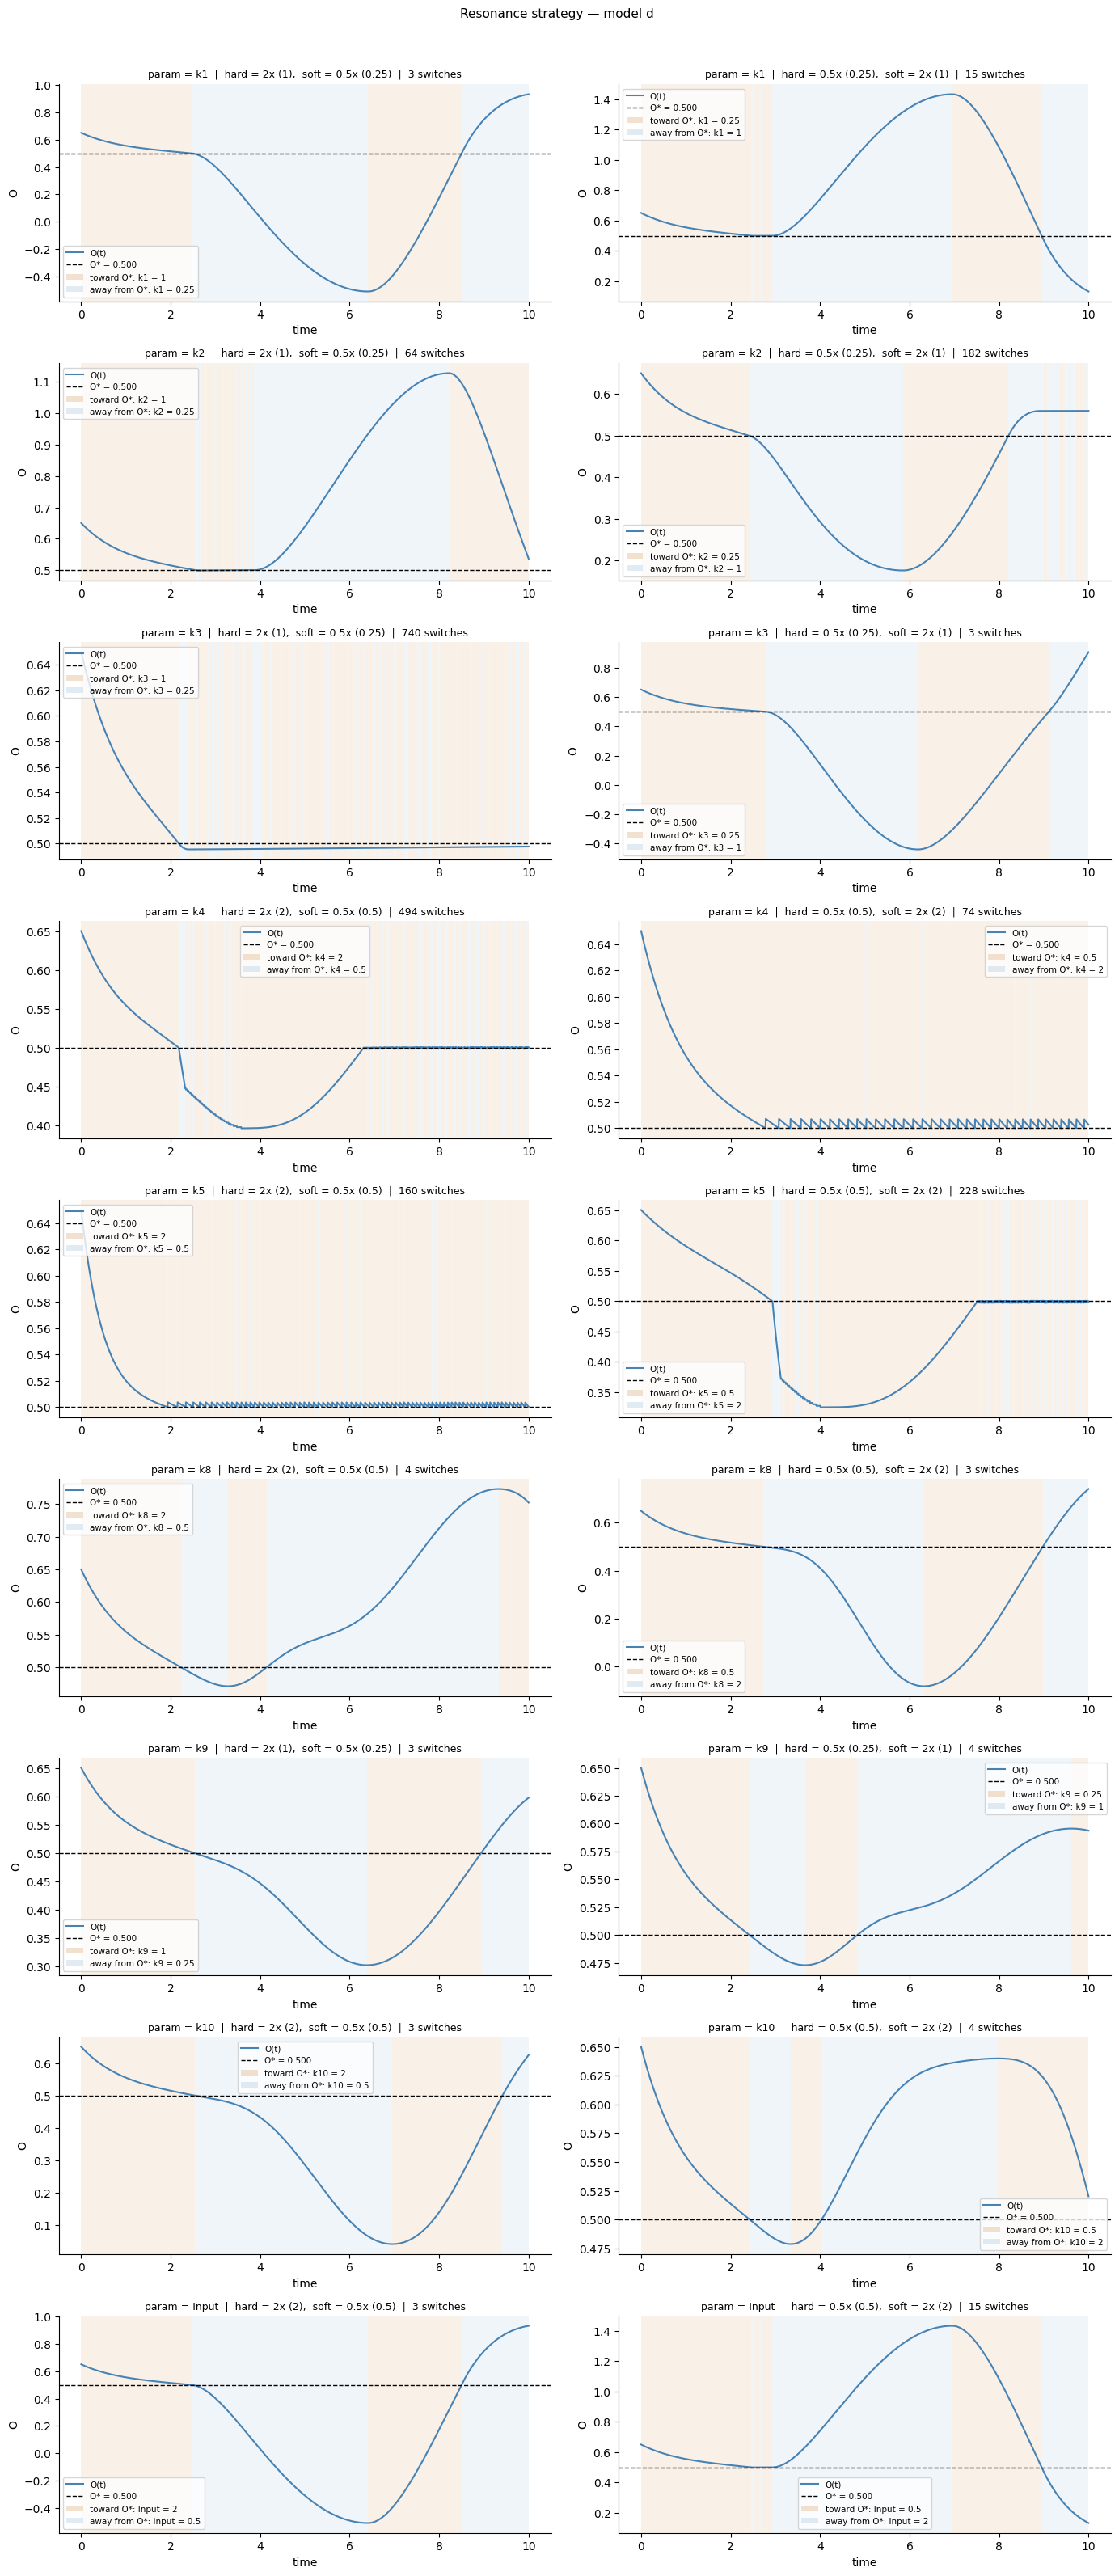

In [6]:
rs = run_resonance_demo(model_d, t_end=10)
# rs = run_resonance_demo(model_c)

## Sensitization Strategy

Two-stage approach: slowly ramp an RPA parameter to prime the system, then apply
an abrupt treatment. Compared against a no-ramp control.

Model a  |  O* = 0.7500  |  RPA params: ['k1', 'k2', 'k3', 'Input']

  param=k1  variant=down_up ...
  param=k2  variant=down_up ...
  param=k3  variant=down_up ...
  param=Input  variant=down_up ...
Done.


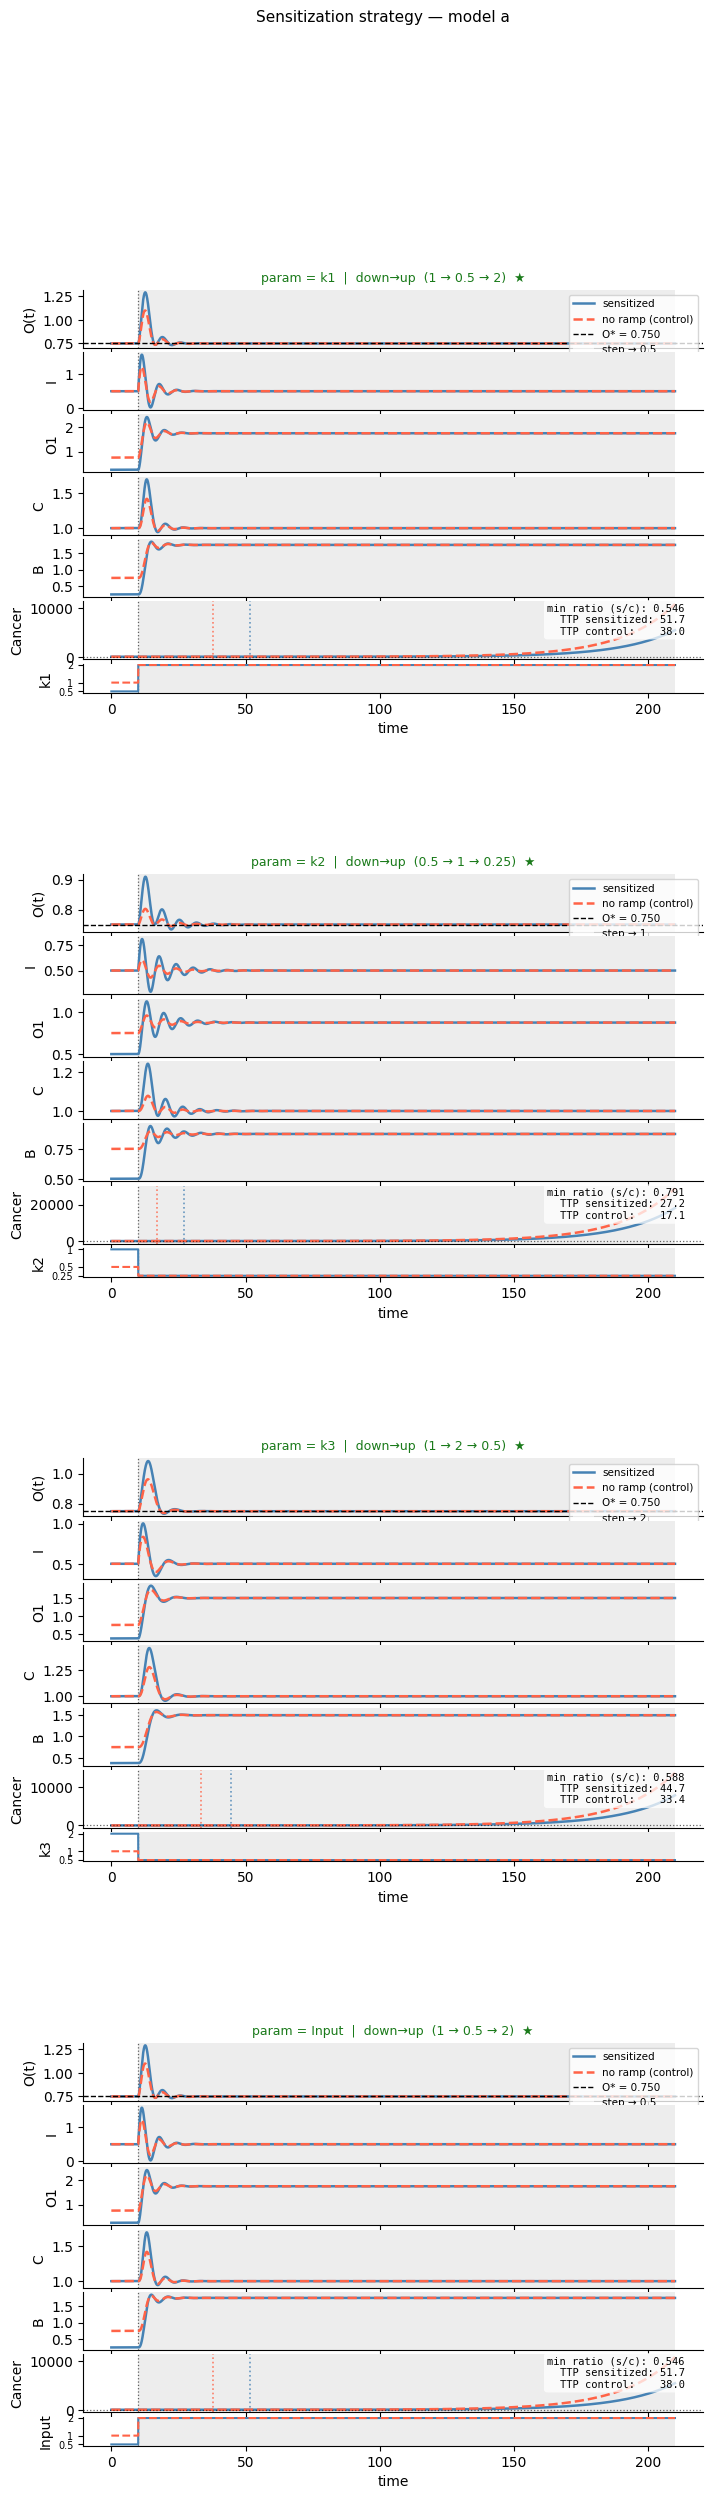

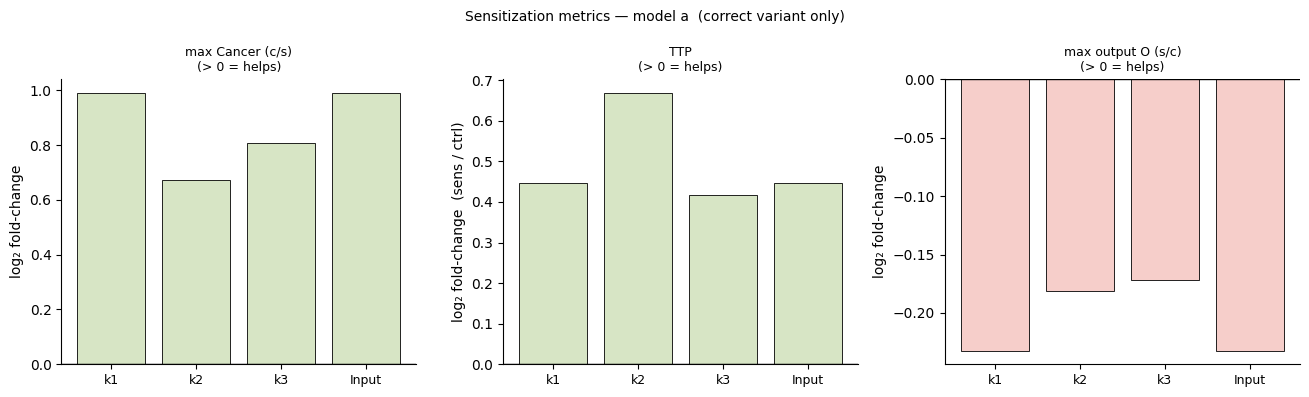

In [7]:
run_sensitization_demo(model_a, ramp_duration=10.0, t_post=200.0,
                       cancer_threshold=2.0, fast_prep=True,
                       start_from_primed_ss=True, variant='down_up')

  param=k1  variant=down_up ...
  param=k2  variant=down_up ...
  param=k3  variant=down_up ...
  param=Input  variant=down_up ...
Done.


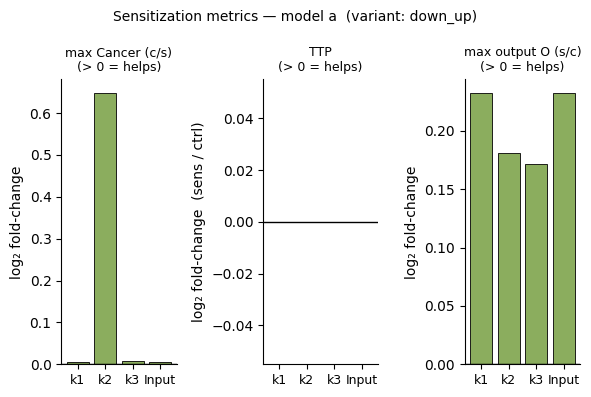

  param=k1  variant=down_up ...
  param=k2  variant=down_up ...
  param=k5  variant=down_up ...
  param=k7  variant=down_up ...
  param=Input  variant=down_up ...
Done.


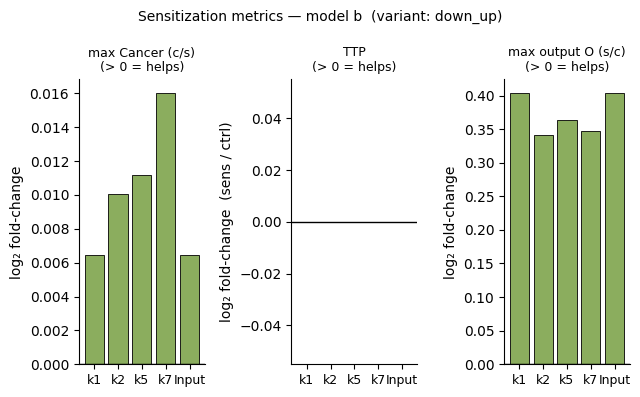

  param=k1  variant=down_up ...
  param=k2  variant=down_up ...
  param=k3  variant=down_up ...
  param=k9  variant=down_up ...
  param=k10  variant=down_up ...
  param=k11  variant=down_up ...
  param=Input  variant=down_up ...
Done.


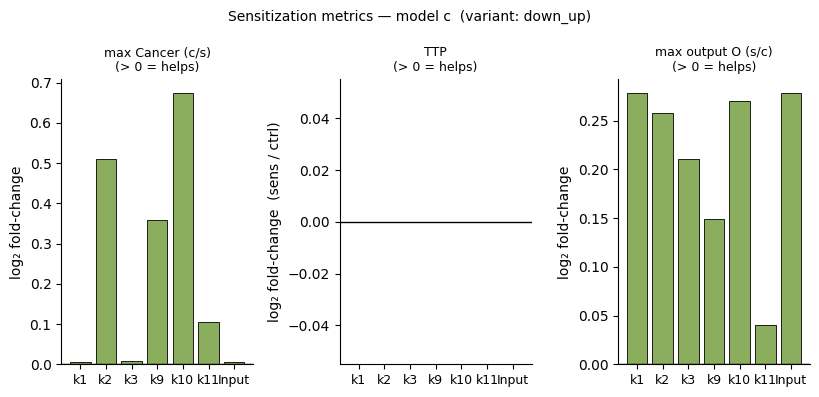

  param=k1  variant=down_up ...
  param=k2  variant=down_up ...
  param=k3  variant=down_up ...
  param=k4  variant=down_up ...
  param=k5  variant=down_up ...
  param=k8  variant=down_up ...
  param=k9  variant=down_up ...
  param=k10  variant=down_up ...
  param=Input  variant=down_up ...
Done.


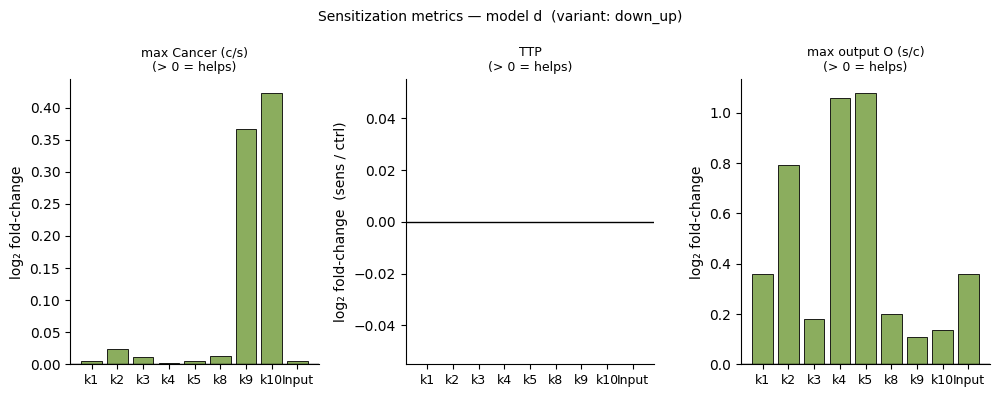

  param=k1  variant=down_up ...
  param=k2  variant=down_up ...
  param=k6  variant=down_up ...
  param=k7  variant=down_up ...
  param=k8  variant=down_up ...
  param=Input  variant=down_up ...
Done.


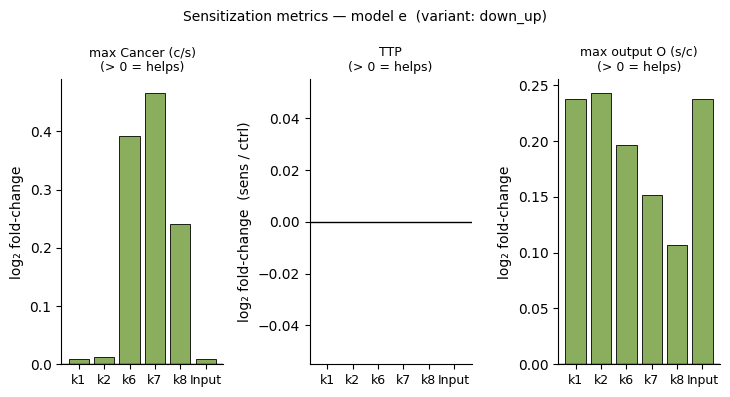

  param=k1  variant=down_up ...
  param=k2  variant=down_up ...
  param=k3  variant=down_up ...
  param=k6  variant=down_up ...
  param=k7  variant=down_up ...
  param=k8  variant=down_up ...
  param=k11  variant=down_up ...
  param=k12  variant=down_up ...
  param=k13  variant=down_up ...
  param=Input  variant=down_up ...
Done.


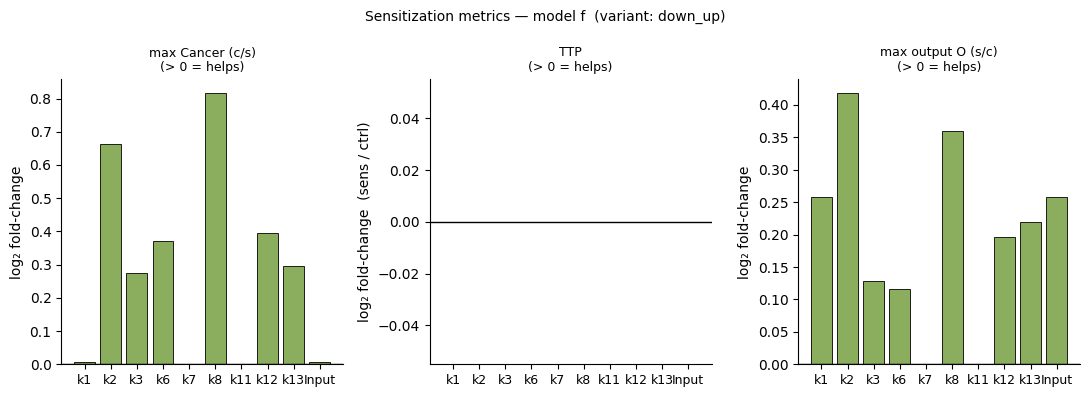

In [8]:
from rpa_control.paths import save_fig

RAMP_DURATION    = 30.0
T_POST           = 20.0
DT               = 0.005
CANCER_THRESHOLD = 2.0
VARIANT          = 'down_up'
GREEN            = '#8bad5e'
RED              = '#f6ceca'
INF_CAP          = np.log2(20)
BAR_WIDTH        = 0.8
INCHES_PER_BAR   = 0.3

for model in ALL_MODELS:
    if 'Cancer' not in model.state_vars:
        continue

    ss = SensitizationStrategy(model)
    ss.simulate_all(ramp_duration=RAMP_DURATION, t_post=T_POST, dt=DT,
                    fast_prep=True, start_from_primed_ss=True, variant=VARIANT)

    cidx = model.state_vars.index('Cancer')
    oidx = model.output_idx

    params_out, lfc_cancer, lfc_ttp, lfc_O, lfc_O_is_inf, bar_variants, pct_O, pct_O_is_inf = [], [], [], [], [], [], [], []

    for param in model.rpa_params:
        res             = ss.results[param][VARIANT]
        t_r, y_r, yc_r = res['t'], res['y'], res['y_ctrl']
        t_sw            = res['ramp_duration']
        n_rp            = np.searchsorted(t_r, t_sw, side='right')

        c_s, c_c = y_r[cidx, n_rp:], yc_r[cidx, n_rp:]
        o_s, o_c = y_r[oidx, n_rp:], yc_r[oidx, n_rp:]

        if VARIANT == 'up_down':
            ext_cs, ext_cc = c_s.min(), c_c.min()
            lfc_c = np.log2(ext_cc / ext_cs) if ext_cc > 0 and ext_cs > 0 else np.nan
        else:
            ext_cs, ext_cc = c_s.max(), c_c.max()
            lfc_c = np.log2(ext_cc / ext_cs) if ext_cc > 0 and ext_cs > 0 else np.nan

        def _ttp(traj, _t=t_r[n_rp:]):
            cross = np.where(traj > CANCER_THRESHOLD)[0]
            return _t[cross[0]] if len(cross) else float('inf')

        ttp_s, ttp_c = _ttp(c_s), _ttp(c_c)
        if   np.isfinite(ttp_s) and np.isfinite(ttp_c) and ttp_c > 0:
            lfc_t = np.log2(ttp_s / ttp_c)
        elif not np.isfinite(ttp_s) and np.isfinite(ttp_c):
            lfc_t = INF_CAP
        elif np.isfinite(ttp_s) and not np.isfinite(ttp_c):
            lfc_t = -INF_CAP
        else:
            lfc_t = np.nan

        if VARIANT == 'up_down':
            ext_os, ext_oc = o_s.min(), o_c.min()
            if ext_oc <= 0 and ext_os > 0:
                lfc_o, inf_o = INF_CAP, True
            elif ext_os > 0 and ext_oc > 0:
                lfc_o, inf_o = np.log2(ext_oc / ext_os), False
            else:
                lfc_o, inf_o = np.nan, False
        else:
            ext_os, ext_oc = o_s.max(), o_c.max()
            if ext_oc <= 0 and ext_os > 0:
                lfc_o, inf_o = INF_CAP, True
            elif ext_oc > 0 and ext_os > 0:
                lfc_o, inf_o = np.log2(ext_os / ext_oc), False
            else:
                lfc_o, inf_o = np.nan, False

        if ext_oc > 0:
            pct_o  = ((ext_os - ext_oc) / ext_oc) * 100
            inf_po = False
        elif ext_oc <= 0 and ext_os > 0:
            pct_o, inf_po = float('inf'), True
        else:
            pct_o, inf_po = np.nan, False

        params_out.append(param)
        lfc_cancer.append(lfc_c)
        lfc_ttp.append(lfc_t)
        lfc_O.append(lfc_o)
        lfc_O_is_inf.append(inf_o)
        pct_O.append(pct_o)
        pct_O_is_inf.append(inf_po)
        bar_variants.append(VARIANT)

    if not params_out:
        continue

    x         = np.arange(len(params_out))
    n_bars    = len(params_out)
    fig_width = max(6, INCHES_PER_BAR * n_bars * 3 + 2)
    fig2, (ax_r, ax_t, ax_o) = plt.subplots(1, 3, figsize=(fig_width, 4))

    colors_r = [GREEN if v > 0 else RED for v in lfc_cancer]
    ax_r.bar(x, lfc_cancer, color=colors_r, edgecolor='k', linewidth=0.6,
             width=BAR_WIDTH)
    ax_r.axhline(0, color='k', lw=1)
    ax_r.set_xticks(x); ax_r.set_xticklabels(params_out, fontsize=9)
    _c_lbl = 'min Cancer (c/s)' if VARIANT == 'up_down' else 'max Cancer (c/s)'
    _o_lbl = 'min output O (c/s)' if VARIANT == 'up_down' else 'max output O (s/c)'
    ax_r.set_ylabel('log₂ fold-change')
    ax_r.set_title(_c_lbl + chr(10) + '(> 0 = helps)', fontsize=9)
    ax_r.spines['top'].set_visible(False); ax_r.spines['right'].set_visible(False)

    colors_t = [GREEN if (not np.isnan(v) and v > 0) else RED for v in lfc_ttp]
    ax_t.bar(x, lfc_ttp, color=colors_t, edgecolor='k', linewidth=0.6, width=BAR_WIDTH)
    ax_t.axhline(0, color='k', lw=1)
    for xi, v in zip(x, lfc_ttp):
        if np.isfinite(v) and abs(v) >= INF_CAP * 0.95:
            ax_t.text(xi, v + 0.05 * np.sign(v), '∞',
                      ha='center', va='bottom' if v > 0 else 'top', fontsize=9)
    ax_t.set_xticks(x); ax_t.set_xticklabels(params_out, fontsize=9)
    ax_t.set_ylabel('log₂ fold-change  (sens / ctrl)')
    ax_t.set_title('TTP' + chr(10) + '(> 0 = helps)', fontsize=9)
    ax_t.spines['top'].set_visible(False); ax_t.spines['right'].set_visible(False)

    lfc_O_disp = [np.clip(v, -INF_CAP, INF_CAP) for v in lfc_O]
    colors_o   = [GREEN if v > 0 else RED for v in lfc_O_disp]
    ax_o.bar(x, lfc_O_disp, color=colors_o, edgecolor='k', linewidth=0.6, width=BAR_WIDTH)
    ax_o.axhline(0, color='k', lw=1)
    for xi, v_disp, v_raw, is_inf in zip(x, lfc_O_disp, lfc_O, lfc_O_is_inf):
        if is_inf:
            ax_o.text(xi, v_disp + 0.05 * np.sign(v_disp), '∞',
                      ha='center', va='bottom' if v_disp > 0 else 'top', fontsize=9)
        elif np.isfinite(v_raw) and abs(v_raw) > abs(v_disp) * 1.01:
            ax_o.text(xi, v_disp + 0.05 * np.sign(v_disp),
                      f'▲{v_raw:.1f}',
                      ha='center', va='bottom' if v_disp > 0 else 'top', fontsize=8)
    ax_o.set_xticks(x); ax_o.set_xticklabels(params_out, fontsize=9)
    ax_o.set_ylabel('log₂ fold-change')
    ax_o.set_title(_o_lbl + chr(10) + '(> 0 = helps)', fontsize=9)
    ax_o.spines['top'].set_visible(False); ax_o.spines['right'].set_visible(False)

    fig2.suptitle(f'Sensitization metrics — model {model.name}  (variant: {VARIANT})',
                  fontsize=10)
    plt.tight_layout()
    plt.show()

## Separation-of-Timescales Strategy

Periodic intermittent treatment with automatically determined T_on and T_off:
- T_on  = time when Cancer reaches its minimum under constant treatment
- T_off = time until all homeostatic variables recover to within `recovery_frac` of SS

Model e  |  O* = 0.5000  |  RPA params: ['k1', 'k2', 'k6', 'k7', 'k8', 'Input']

  param=k1  scale=2x ...
    T_on = 9.375,  T_off = 15.215
  param=k1  scale=0.5x ...
    → non-successful (Cancer does not decay)
  param=k2  scale=2x ...
    → non-successful (Cancer does not decay)
  param=k2  scale=0.5x ...
    T_on = 10.015,  T_off = 15.515
  param=k6  scale=2x ...
    T_on = 7.295,  T_off = 11.115
  param=k6  scale=0.5x ...
    → non-successful (Cancer does not decay)
  param=k7  scale=2x ...
    → non-successful (Cancer does not decay)
  param=k7  scale=0.5x ...
    T_on = 5.995,  T_off = 10.480
  param=k8  scale=2x ...
    → non-successful (Cancer does not decay)
  param=k8  scale=0.5x ...
    → non-successful (Cancer does not decay)
  param=Input  scale=2x ...
    T_on = 9.375,  T_off = 15.215
  param=Input  scale=0.5x ...
    → non-successful (Cancer does not decay)
Done.


/home/amir/RL/autodiff-control/src/rpa_control/strategies/sot.py:376: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


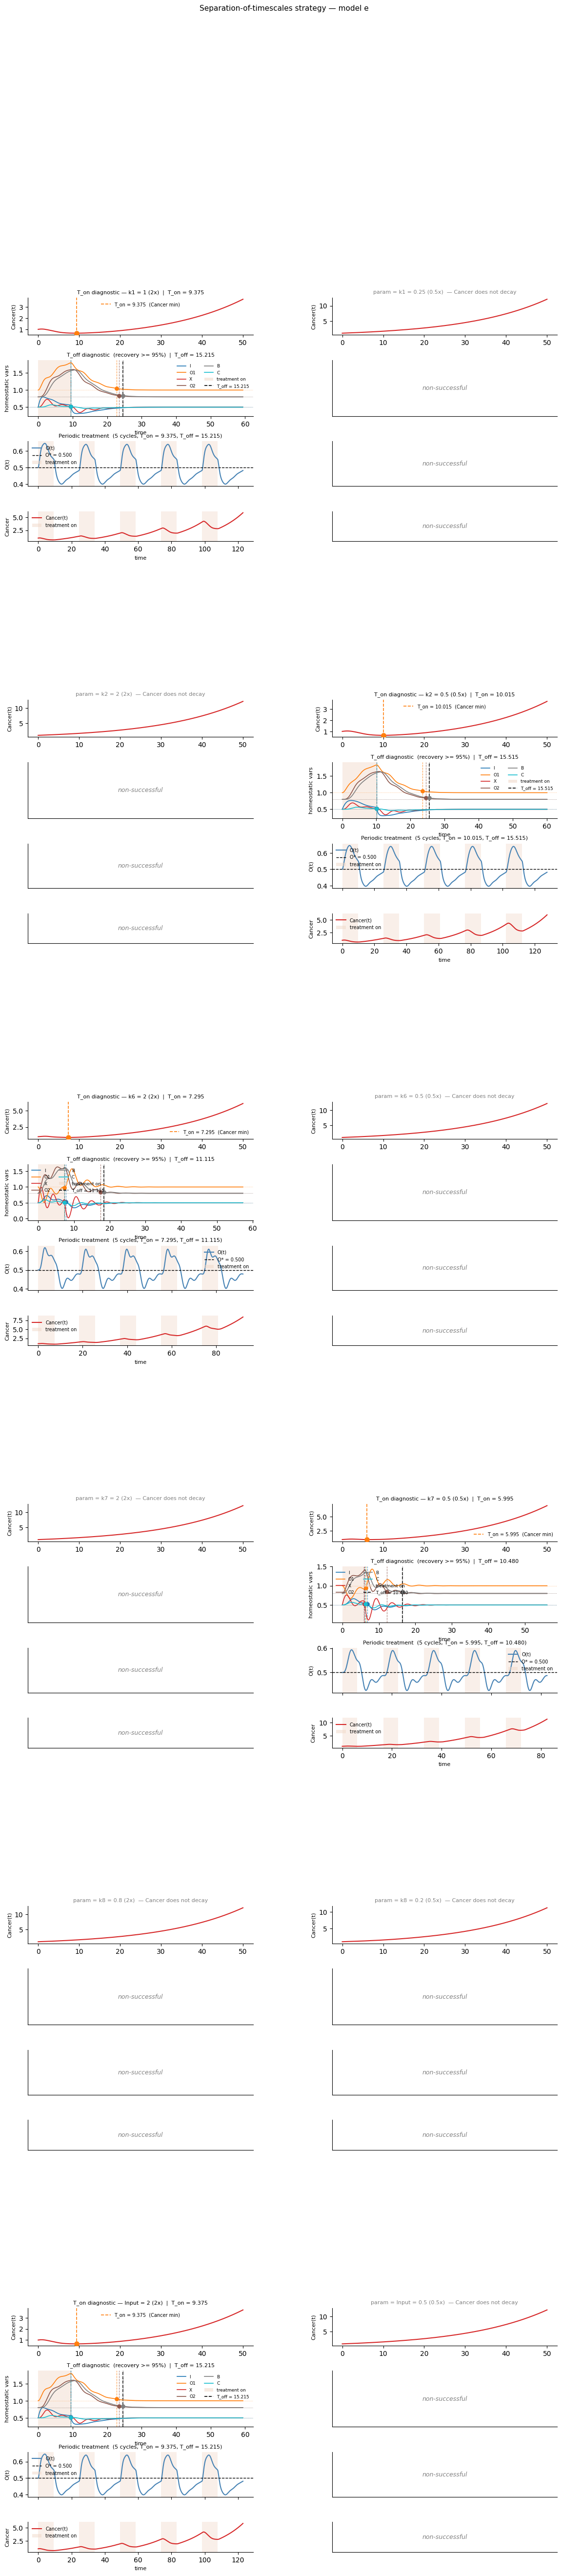

In [9]:
sot = run_sot_demo(model_e, n_cycles=5, t_max_ton=50, t_max_toff=50, recovery_frac=0.95)

## Stepped input (RPA validation)

Ramp Input through [0.2, 0.4, 0.6, 0.8, 1.0] in steps. The output O should
return to the same steady state O* after each step (RPA behaviour).

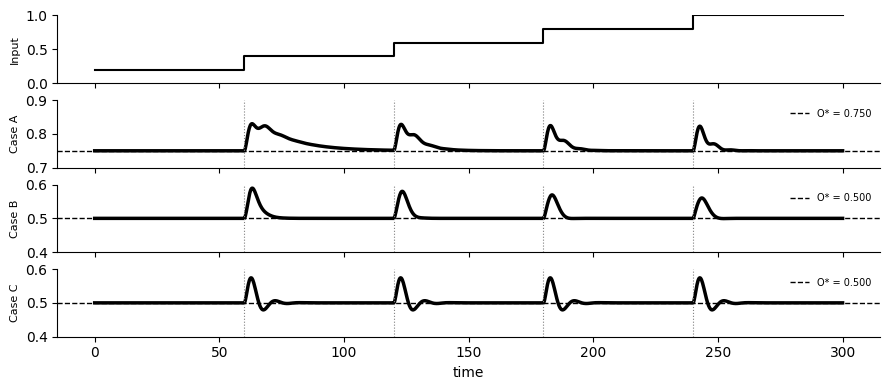

In [10]:
input_vals = [0.2, 0.4, 0.6, 0.8, 1.0]
dt_step    = 60

t_stairs = np.repeat(np.arange(len(input_vals) + 1) * dt_step, 2)[1:-1]
i_stairs = np.repeat(input_vals, 2)
t_vlines = np.arange(1, len(input_vals)) * dt_step
x_ticks  = np.arange(0, len(input_vals) * dt_step + 1, 50)

# ── Models a, b, c ────────────────────────────────────────────────────────────
models_abc = [model_a, model_b, model_c]
ylims_abc  = [(0.7, 0.9), (0.4, 0.6), (0.4, 0.6)]
n = len(models_abc)

fig, axes = plt.subplots(n + 1, 1, figsize=(9, (n + 1) * 1.0), sharex=True)

axes[0].plot(t_stairs, i_stairs, color='k', lw=1.5)
axes[0].set_ylim(0, 1.0)
axes[0].set_ylabel('Input', fontsize=8)
axes[0].tick_params(labelbottom=False)
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

for i, (model, ylim) in enumerate(zip(models_abc, ylims_abc)):
    ax = axes[i + 1]
    O_star  = eval_ss(model, {'Input': input_vals[0]})[model.output_idx]
    t_cat, y_cat = stepped_trajectory(model, 'Input', input_vals, [dt_step]*len(input_vals))
    ax.plot(t_cat, y_cat[model.output_idx], color='k', lw=2.5)
    ax.axhline(O_star, color='k', ls='--', lw=1, label=f'O* = {O_star:.3f}')
    for t_v in t_vlines:
        ax.axvline(t_v, color='grey', ls=':', lw=0.8)
    ax.set_ylim(*ylim)
    ax.set_ylabel(f'Case {model.name.upper()}', fontsize=8)
    ax.legend(fontsize=7, frameon=False)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

axes[-1].set_xlabel('time')
axes[-1].set_xticks(x_ticks)
plt.tight_layout(h_pad=0.2)
plt.show()

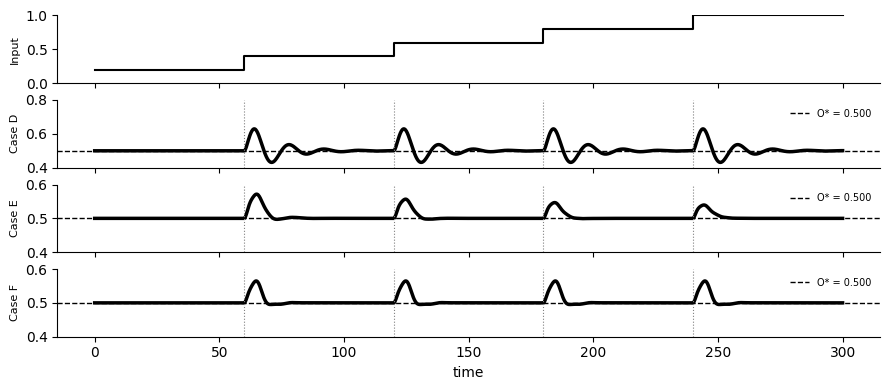

In [11]:
# ── Models d, e, f ────────────────────────────────────────────────────────────
models_def = [model_d, model_e, model_f]
ylims_def  = [(0.4, 0.8), (0.4, 0.6), (0.4, 0.6)]
n = len(models_def)

fig, axes = plt.subplots(n + 1, 1, figsize=(9, (n + 1) * 1.0), sharex=True)

axes[0].plot(t_stairs, i_stairs, color='k', lw=1.5)
axes[0].set_ylim(0, 1.0)
axes[0].set_ylabel('Input', fontsize=8)
axes[0].tick_params(labelbottom=False)
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

for i, (model, ylim) in enumerate(zip(models_def, ylims_def)):
    ax = axes[i + 1]
    O_star  = eval_ss(model, {'Input': input_vals[0]})[model.output_idx]
    t_cat, y_cat = stepped_trajectory(model, 'Input', input_vals, [dt_step]*len(input_vals))
    ax.plot(t_cat, y_cat[model.output_idx], color='k', lw=2.5)
    ax.axhline(O_star, color='k', ls='--', lw=1, label=f'O* = {O_star:.3f}')
    for t_v in t_vlines:
        ax.axvline(t_v, color='grey', ls=':', lw=0.8)
    ax.set_ylim(*ylim)
    ax.set_ylabel(f'Case {model.name.upper()}', fontsize=8)
    ax.legend(fontsize=7, frameon=False)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

axes[-1].set_xlabel('time')
axes[-1].set_xticks(x_ticks)
plt.tight_layout(h_pad=0.2)
plt.show()